# T12.5 — Hampi Monument Identifier: CLIP Evaluation Notebook

This notebook lets you:
1. Test CLIP predictions on individual images
2. Run batch evaluation on a folder of test images
3. Visualise confidence distributions
4. Tune prompt templates for better accuracy

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Update imports to match the new clip_model.py
from model.clip_model import HampiCLIPModel, LABELS as MONUMENT_NAMES
from utils.helpers import get_monument_info, confidence_color
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Create FOLDER_TO_CLASS dynamically since it was removed from clip_model.py
FOLDER_TO_CLASS = {label: label for label in MONUMENT_NAMES}

print('Imports OK')

Imports OK


## 1. Load Model

In [2]:
model = HampiCLIPModel()
model.load()
print('CLIP model loaded on:', model.device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ Linear Probe Classifier loaded!
✅ CLIP loaded on cpu
CLIP model loaded on: cpu


## 2. Single Image Prediction

Inference time: 1493.9 ms

  1. Elephant_Stables                ██████████                                 26.7%
  2. Lotus_Mahal                     ███████                                    17.8%
  3. Hemakuta_temple_hill_complex    █████                                      14.8%
  4. Hampi_Bazaar                    █████                                      13.8%
  5. Monolithic_Bull                 █████                                      13.8%


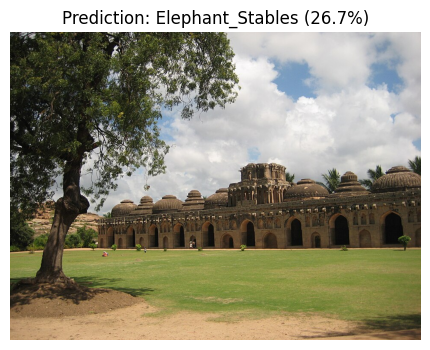

In [3]:
# Change this path to any monument image
IMAGE_PATH = '../data/test_images/Elephant_Stables/005_960px-Elephant_stables_(27).jpg.jpg'

if os.path.exists(IMAGE_PATH):
    image = Image.open(IMAGE_PATH).convert('RGB')
    preds, latency = model.predict(image, top_k=5)

    print(f'Inference time: {latency:.1f} ms\n')
    for p in preds:
        bar = '█' * int(p['confidence'] * 40)
        print(f"  {p['rank']}. {p['name']:<30s}  {bar:<40s}  {p['confidence']*100:5.1f}%")

    # Show image
    plt.figure(figsize=(6, 4))
    plt.imshow(image)
    plt.title(f"Prediction: {preds[0]['name']} ({preds[0]['confidence']*100:.1f}%)")
    plt.axis('off')
    plt.show()
else:
    print(f'Image not found at {IMAGE_PATH} — please verify the path.')

## 3. Batch Evaluation

In [4]:
# Batch Evaluation Cell 
import os
import time
from PIL import Image, ImageOps

TEST_DIR = '../data/test_images'

def pad_to_square(img, fill_color=(0, 0, 0)):
    # Pads aspect ratio to a square to prevent bad center crops by CLIP
    x, y = img.size
    size = max(x, y)
    new_img = Image.new('RGB', (size, size), fill_color)
    new_img.paste(img, (int((size - x) / 2), int((size - y) / 2)))
    return new_img

if not os.path.isdir(TEST_DIR):
    print(f'Test directory not found: {TEST_DIR}')
else:
    results = []
    
    # We must match the folder names EXACTLY to the new LABELS in clip_model.py
    # Some folders might have slightly different names than our new LABELS
    
    for folder_name in os.listdir(TEST_DIR):
        folder = os.path.join(TEST_DIR, folder_name)
        if not os.path.isdir(folder):
            continue
            
        print(f"Evaluating folder: {folder_name}")
        for fname in os.listdir(folder):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                continue
            try:
                img = Image.open(os.path.join(folder, fname)).convert('RGB')
                
                # Apply padding here before prediction
                img_padded = pad_to_square(img)
                preds, lat = model.predict(img_padded, top_k=3)
                
            except Exception as e:
                print(f'Skipping corrupted image {fname}: {e}')
                continue
            
            # --- FIX: Direct comparison, no FOLDER_TO_CLASS mapping needed ---
            top1_correct = (preds[0]['name'] == folder_name)
            top3_correct = any(p['name'] == folder_name for p in preds)
            
            results.append({
                'true': folder_name,
                'pred': preds[0]['name'],
                'conf': preds[0]['confidence'],
                'top1': top1_correct,
                'top3': top3_correct,
                'latency': lat,
            })

    if results:
        top1 = sum(r['top1'] for r in results) / len(results)
        top3 = sum(r['top3'] for r in results) / len(results)
        avg_conf = sum(r['conf'] for r in results) / len(results)
        avg_lat = sum(r['latency'] for r in results) / len(results)

        print(f'\nTotal images evaluated : {len(results)}')
        print(f'Top-1 Accuracy         : {top1*100:.1f}%')
        print(f'Top-3 Accuracy         : {top3*100:.1f}%')
        print(f'Avg confidence (top-1) : {avg_conf*100:.1f}%')
        print(f'Avg latency            : {avg_lat:.1f} ms')

Evaluating folder: Elephant_Stables
Evaluating folder: Hampi_Bazaar
Evaluating folder: Hemakuta_temple_hill_complex
Evaluating folder: Lotus_Mahal
Evaluating folder: Monolithic_Bull
Evaluating folder: Royal_Centre

Total images evaluated : 72
Top-1 Accuracy         : 65.3%
Top-3 Accuracy         : 77.8%
Avg confidence (top-1) : 24.0%
Avg latency            : 1205.5 ms


## 4. Confidence Distribution Plot

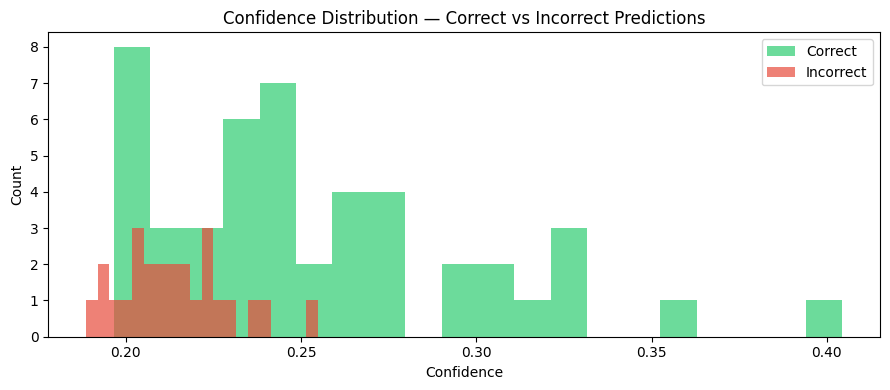

In [5]:
# Requires 'results' from cell above
if 'results' in dir() and results:
    correct_confs = [r['conf'] for r in results if r['top1']]
    wrong_confs   = [r['conf'] for r in results if not r['top1']]

    plt.figure(figsize=(9, 4))
    plt.hist(correct_confs, bins=20, alpha=0.7, color='#2ecc71', label='Correct')
    plt.hist(wrong_confs,   bins=20, alpha=0.7, color='#e74c3c', label='Incorrect')
    plt.xlabel('Confidence')
    plt.ylabel('Count')
    plt.title('Confidence Distribution — Correct vs Incorrect Predictions')
    plt.legend()
    plt.tight_layout()
    plt.show()